# TTT Gradient Analysis

Comparing surrogate vs non-surrogate gradients for k, q, v inputs.

In [21]:
!git clone https://github.com/Ja-Crispy/macrogpt-jax.git -b surrogate-ttt

Cloning into 'macrogpt-jax'...
remote: Enumerating objects: 463, done.
remote: Counting objects: 100% (463/463), done.
remote: Compressing objects: 100% (285/285), done.
remote: Total 463 (delta 193), reused 434 (delta 167), pack-reused 0 (from 0)
Receiving objects: 100% (463/463), 5.00 MiB | 10.08 MiB/s, done.
Resolving deltas: 100% (193/193), done.


In [23]:
%cd macrogpt-jax

/content/macrogpt-jax


In [8]:
!ls

AGENTS.md  random_adapter  requirements.txt  ueaj
CLAUDE.md  README.md	   scripts


In [10]:
%pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.7/515.7 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 127.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.9/146.9 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [24]:
import jax
import jax.numpy as jnp
from flax import nnx
from flax.nnx import rnglib as rng
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.insert(0, '../../..')

from ueaj.model.ttt import TTTModel
from ueaj.model import GMLP

In [25]:
# Config
model_d, hidden_d = 128, 512
batch_size, seq_len = 1, 200
seed = 42

In [26]:
# Create models
model_surr = TTTModel(model_d, hidden_d, GMLP, surrogate=True, rngs=rng.Rngs(seed))
model_nonsurr = TTTModel(model_d, hidden_d, GMLP, surrogate=False, rngs=rng.Rngs(seed))

# Generate k, q, v directly
key = jax.random.PRNGKey(123)
k_key, v_key, q_key = jax.random.split(key, 3)
k = jax.random.normal(k_key, (batch_size, seq_len, hidden_d))
v = jax.random.normal(v_key, (batch_size, seq_len, hidden_d))
q = jax.random.normal(q_key, (batch_size, seq_len, hidden_d))

print(f"k, v, q shapes: {k.shape}")

k, v, q shapes: (1, 200, 512)


In [27]:
def compute_grads(model, k, v, q, grad_output):
    """Compute gradients w.r.t. k, v, q using VJP."""
    def forward(k, v, q):
        return model.apply_ttt(k, v, q)

    output, vjp_fn = jax.vjp(forward, k, v, q)
    grad_k, grad_v, grad_q = vjp_fn(grad_output)
    return grad_k, grad_v, grad_q, output

def rms_error_per_token(grad_surr, grad_nonsurr):
    """Compute RMS error per token position, averaged over batch."""
    diff = grad_surr - grad_nonsurr
    rms_per_batch = jnp.sqrt(jnp.mean(diff**2, axis=2))  # (batch, seq_len)
    return rms_per_batch.mean(axis=0)  # (seq_len,)

def rms_norm_per_token(grad):
    """Compute RMS norm per token position, averaged over batch."""
    rms_per_batch = jnp.sqrt(jnp.mean(grad**2, axis=2))  # (batch, seq_len)
    return rms_per_batch.mean(axis=0)  # (seq_len,)

def cosine_similarity_per_token(grad_surr, grad_nonsurr):
    """Compute cosine similarity per token position, averaged over batch."""
    # Compute per batch element
    dot_product = jnp.sum(grad_surr * grad_nonsurr, axis=2)  # (batch, seq_len)
    norm_surr = jnp.linalg.norm(grad_surr, axis=2)  # (batch, seq_len)
    norm_nonsurr = jnp.linalg.norm(grad_nonsurr, axis=2)  # (batch, seq_len)
    cosine_sim = dot_product / (norm_surr * norm_nonsurr + 1e-8)  # (batch, seq_len)
    return cosine_sim.mean(axis=0)  # (seq_len,)

In [28]:
# Random output gradient
grad_output = jax.random.normal(jax.random.PRNGKey(456), (batch_size, seq_len, hidden_d))

# Compute gradients
print("Computing gradients...")
gk_surr, gv_surr, gq_surr, _ = compute_grads(model_surr, k, v, q, grad_output)
gk_nonsurr, gv_nonsurr, gq_nonsurr, _ = compute_grads(model_nonsurr, k, v, q, grad_output)
print("✓ Done")

Computing gradients...
✓ Done


In [29]:
# Compute metrics per token
cos_k = cosine_similarity_per_token(gk_surr, gk_nonsurr)
cos_v = cosine_similarity_per_token(gv_surr, gv_nonsurr)
rms_q = rms_error_per_token(gq_surr, gq_nonsurr)

norm_q = rms_norm_per_token(gq_nonsurr)

print(f"Cosine similarity ranges:")
print(f"  k: [{cos_k.min():.4f}, {cos_k.max():.4f}]")
print(f"  v: [{cos_v.min():.4f}, {cos_v.max():.4f}]")
print(f"RMS error range:")
print(f"  q: [{rms_q.min():.4f}, {rms_q.max():.4f}]")

Cosine similarity ranges:
  k: [-0.4340, 0.3694]
  v: [-0.5498, 0.8010]
RMS error range:
  q: [0.0000, 0.0000]


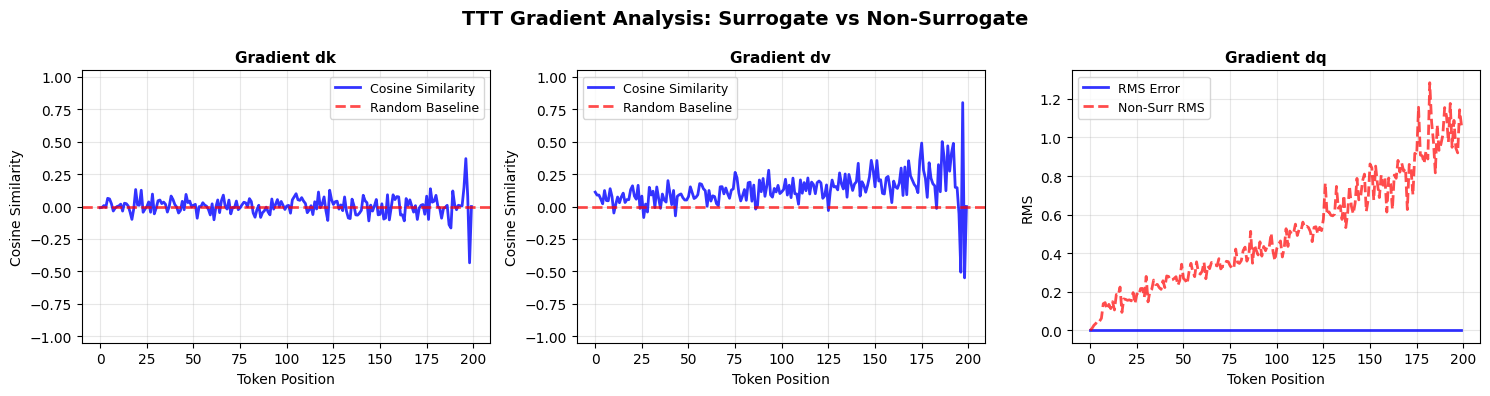

✓ Saved as 'ttt_gradient_comparison.png'


In [30]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('TTT Gradient Analysis: Surrogate vs Non-Surrogate', fontsize=14, fontweight='bold')

tokens = np.arange(seq_len)

# k: Cosine similarity
axes[0].plot(tokens, cos_k, 'b-', linewidth=2, label='Cosine Similarity', alpha=0.8)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2, label='Random Baseline', alpha=0.7)
axes[0].set_xlabel('Token Position', fontsize=10)
axes[0].set_ylabel('Cosine Similarity', fontsize=10)
axes[0].set_title('Gradient dk', fontsize=11, fontweight='bold')
axes[0].set_ylim(-1.05, 1.05)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# v: Cosine similarity
axes[1].plot(tokens, cos_v, 'b-', linewidth=2, label='Cosine Similarity', alpha=0.8)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2, label='Random Baseline', alpha=0.7)
axes[1].set_xlabel('Token Position', fontsize=10)
axes[1].set_ylabel('Cosine Similarity', fontsize=10)
axes[1].set_title('Gradient dv', fontsize=11, fontweight='bold')
axes[1].set_ylim(-1.05, 1.05)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# q: RMS error
axes[2].plot(tokens, rms_q, 'b-', linewidth=2, label='RMS Error', alpha=0.8)
axes[2].plot(tokens, norm_q, 'r--', linewidth=2, label='Non-Surr RMS', alpha=0.7)
axes[2].set_xlabel('Token Position', fontsize=10)
axes[2].set_ylabel('RMS', fontsize=10)
axes[2].set_title('Gradient dq', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ttt_gradient_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved as 'ttt_gradient_comparison.png'")

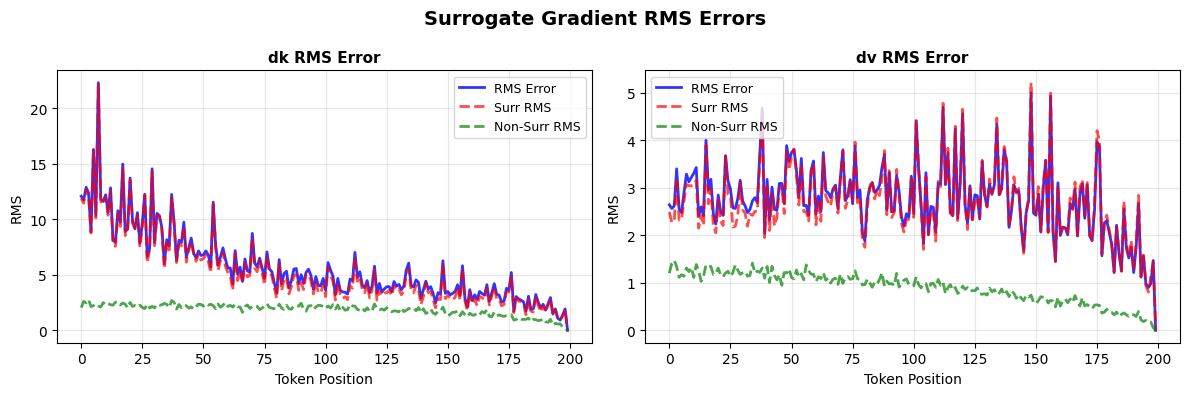

✓ Saved as 'ttt_gradient_rms_errors.png'


In [31]:
# Plot RMS errors for dk and dv with surrogate and non-surrogate RMS for scale
rms_k = rms_error_per_token(gk_surr, gk_nonsurr)
rms_v = rms_error_per_token(gv_surr, gv_nonsurr)
norm_k_surr = rms_norm_per_token(gk_surr)
norm_v_surr = rms_norm_per_token(gv_surr)
norm_k_nonsurr = rms_norm_per_token(gk_nonsurr)
norm_v_nonsurr = rms_norm_per_token(gv_nonsurr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Surrogate Gradient RMS Errors', fontsize=14, fontweight='bold')

tokens = np.arange(seq_len)

# dk RMS error
axes[0].plot(tokens, rms_k, 'b-', linewidth=2, label='RMS Error', alpha=0.8)
axes[0].plot(tokens, norm_k_surr, 'r--', linewidth=2, label='Surr RMS', alpha=0.7)
axes[0].plot(tokens, norm_k_nonsurr, 'g--', linewidth=2, label='Non-Surr RMS', alpha=0.7)
axes[0].set_xlabel('Token Position', fontsize=10)
axes[0].set_ylabel('RMS', fontsize=10)
axes[0].set_title('dk RMS Error', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# dv RMS error
axes[1].plot(tokens, rms_v, 'b-', linewidth=2, label='RMS Error', alpha=0.8)
axes[1].plot(tokens, norm_v_surr, 'r--', linewidth=2, label='Surr RMS', alpha=0.7)
axes[1].plot(tokens, norm_v_nonsurr, 'g--', linewidth=2, label='Non-Surr RMS', alpha=0.7)
axes[1].set_xlabel('Token Position', fontsize=10)
axes[1].set_ylabel('RMS', fontsize=10)
axes[1].set_title('dv RMS Error', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ttt_gradient_rms_errors.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved as 'ttt_gradient_rms_errors.png'")